In [113]:
import pandas as pd
from src.data import read_parquet


In [114]:
FILE_NAMES = ["rating", "movies", "tags", "genome-scores", "genome-tags"]
df_list: list = read_parquet(FILE_NAMES)

In [115]:
rating: pd.DataFrame = df_list[0]
rating

,userId,movieId,rating,timestamp
0,1,296,5.0,2006-05-17 15:34:04
1,1,306,3.5,2006-05-17 12:26:57
2,1,307,5.0,2006-05-17 12:27:08
3,1,665,5.0,2006-05-17 15:13:40
4,1,899,3.5,2006-05-17 12:21:50
...,...,...,...,...
25000090,162541,50872,4.5,2009-04-28 21:16:12
25000091,162541,55768,2.5,2009-04-28 20:53:18
25000092,162541,56176,2.0,2009-04-28 20:31:37
25000093,162541,58559,4.0,2009-04-28 21:17:14


In [116]:
movies: pd.DataFrame = df_list[1]

Посчитаем число пользователей, фильмов, оценок, разреженность

In [117]:
rating["userId"].nunique()

162541

In [118]:
rating['movieId'].nunique()

59047

In [119]:
len(rating[['userId', 'movieId']].drop_duplicates())

25000095

In [120]:
len(rating[['userId', 'movieId']].drop_duplicates()) / (rating["userId"].nunique() * rating['movieId'].nunique())

0.002604839052572928

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Text(0.5, 1.0, 'Распределение значений рейтинга')

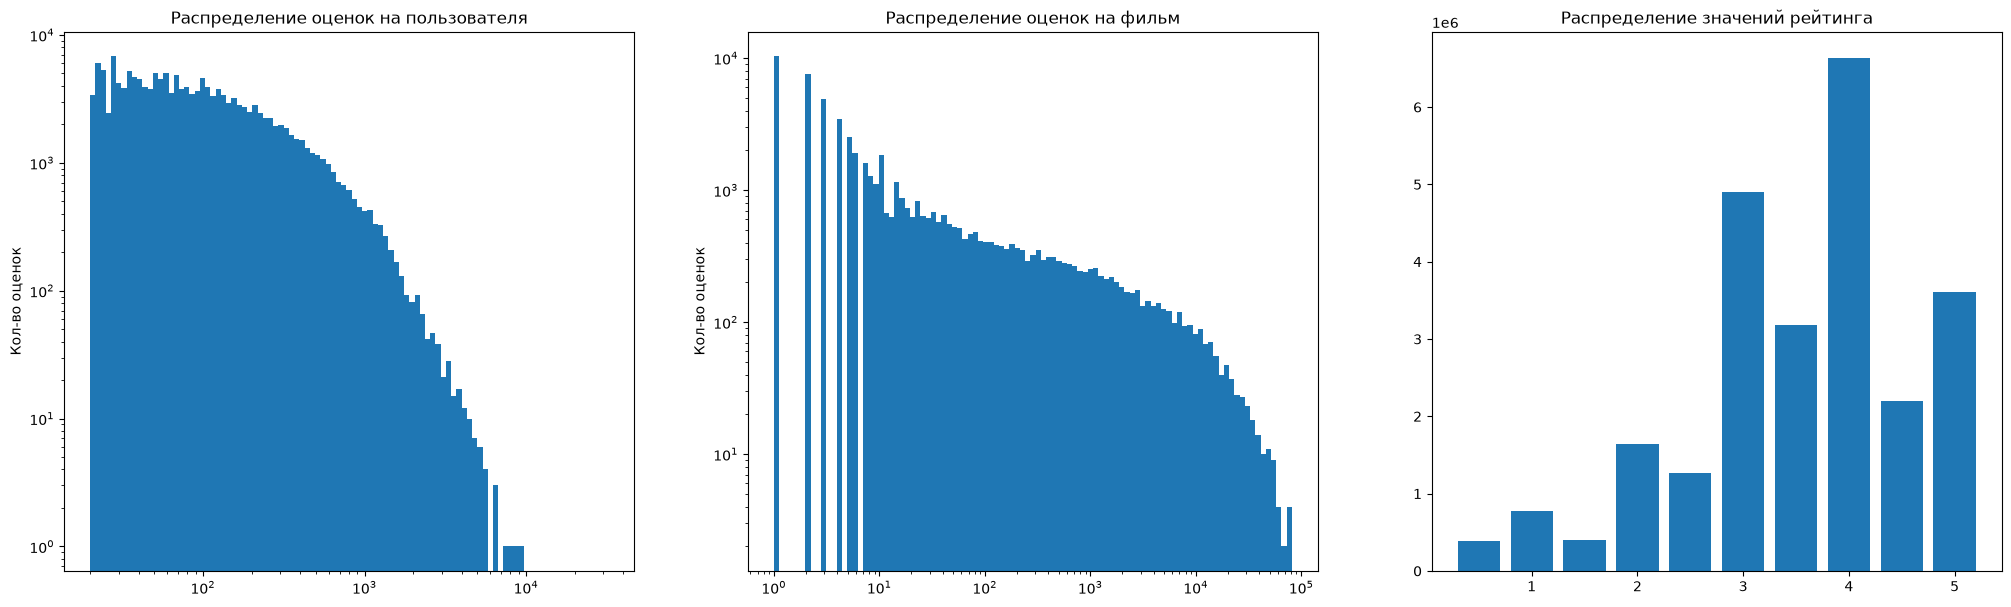

In [122]:
user_group = rating.groupby(
    by=['userId']
).size()

film_group = rating.groupby(
    by=['movieId']
).size()

rate_group = rating.groupby(
    by='rating'
).size()

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(25, 7)
)
bins = np.logspace(np.log10(user_group.min()), np.log10(user_group.max()), 100)
bins2 = np.logspace(np.log10(film_group.min()), np.log10(film_group.max()), 100)

ax1.hist(
    user_group,
    bins=bins
)
ax2.hist(
    film_group,
    bins=bins2
)
ax3.bar(
    rate_group.index,
    rate_group.values,
    width=0.4
)
ax1.set_title('Распределение оценок на пользователя')
ax1.set_ylabel('Кол-во оценок')
ax1.set_xscale("log")
ax1.set_yscale("log")

ax2.set_title('Распределение оценок на фильм')
ax2.set_ylabel('Кол-во оценок')
ax2.set_xscale("log")
ax2.set_yscale("log")

ax3.set_title('Распределение значений рейтинга')



<BarContainer object of 299 artists>

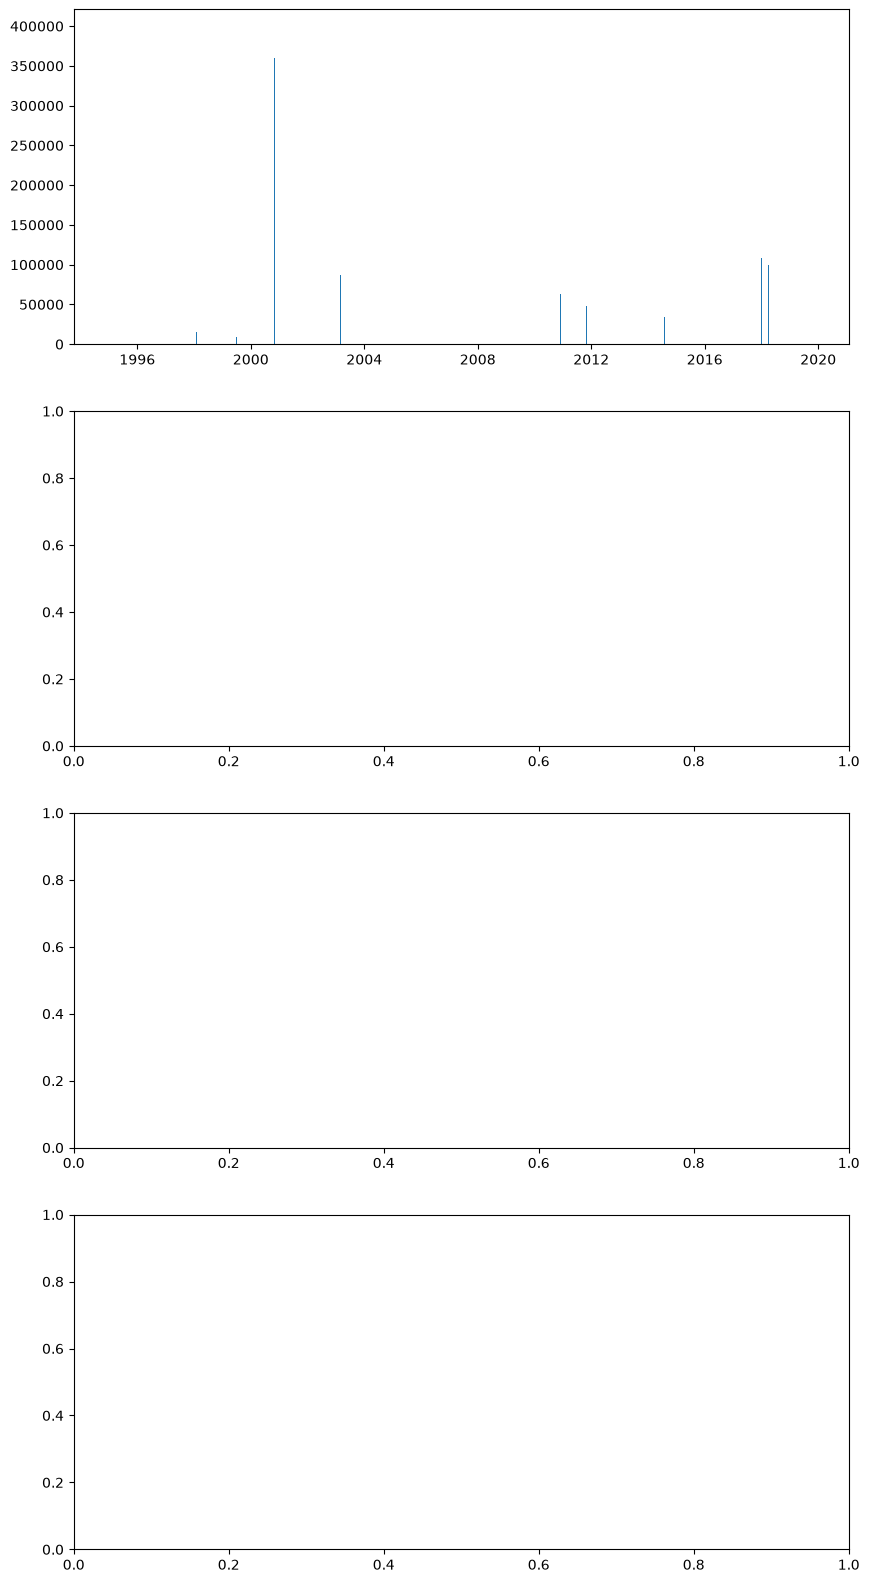

In [123]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1,
    figsize=(10, 20)
)
rate_month = rating.groupby(
    pd.Grouper(key="timestamp", freq="MS")
).size()

ax1.bar(
    rate_month.index,
    rate_month.values,
    width=0.4
)

4 раздел пропущен

Text(0, 0.5, 'Кол во оценок')

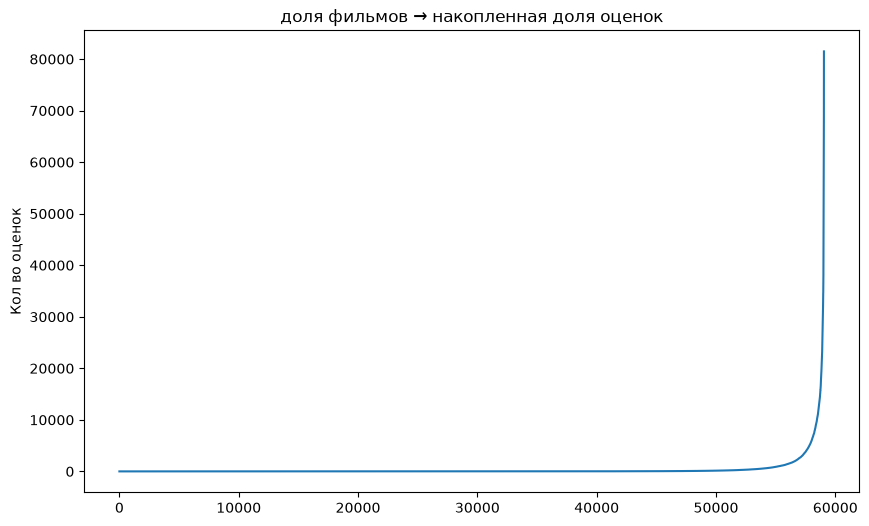

In [137]:
count_films = rating.groupby(
    by='movieId'
).size()
count_films.sort_values(
    inplace=True,
    ascending=True
)


fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6)
)

ax.plot(
    np.arange(len(count_films)),
    count_films.values
)

ax.set_title("доля фильмов → накопленная доля оценок")
ax.set_ylabel('Кол во оценок')

In [138]:
len(count_films < 10)


59047

In [148]:
mean_films = rating[['movieId', 'rating']].groupby(
    by='movieId'
).agg(
    func=np.mean
)
mean_films.sort_values(
    by='rating',
    ascending=False,
    inplace=True
)
mean_films[:10]

,rating
movieId,
191887,5.0
209155,5.0
137359,5.0
175003,5.0
137256,5.0
137274,5.0
137329,5.0
137313,5.0
148254,5.0


In [151]:
mean_films = rating[['movieId', 'rating']].groupby(
    by='movieId'
).size()
mean_films.sort_values(
    ascending=False,
    inplace=True
)
mean_films[:10]

movieId
356     81491
318     81482
296     79672
593     74127
2571    72674
260     68717
480     64144
527     60411
110     59184
2959    58773
dtype: int64

In [154]:
M_range = [100, 1000, 10000]

for m in M_range:
    print(f"M: {m}\n")
    print(
        (count_films / (count_films + m) * mean_films + m / (count_films + m) * mean_films.mean())[:10]
    )

M: 100

movieId
1     57209.911692
2     24130.151402
3     11708.396784
4      2442.953989
5     11618.430279
6     24490.120031
7     12036.278884
8      1280.246063
9      3624.733748
10    28166.845208
dtype: float64
M: 1000

movieId
1     56333.411208
2     23284.421165
3     10915.167849
4      1927.028710
5     10825.954786
6     23643.627370
7     11240.391193
8       951.249635
9      3013.142463
10    27313.638071
dtype: float64
M: 10000

movieId
1     48857.588323
2     17273.282559
3      6584.495847
4       846.399461
5      6514.310005
6     17601.586546
7      6841.648086
8       532.463632
9      1313.212198
10    20989.001867
dtype: float64
